# DocuDevs: Source Locations for Structured Extraction

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/docudevs/python-examples/blob/main/09-source-locations.ipynb)
[![GitHub](https://img.shields.io/badge/GitHub-View_Source-blue?logo=github)](https://github.com/docudevs/python-examples)

This notebook extracts a few key invoice fields from `docs/invoice.pdf`, then fetches the `/job/result/{guid}/source-locations` artifact that maps each JSON field back to page-aware evidence.

The final cell downloads DocuDevs page thumbnails for the processed job and draws the returned bounding boxes on top of the document image so you can inspect exactly where each extracted value came from.


In [ ]:
# Install dependencies (required in Colab)
# Colab includes packages such as gradio and google-genai with their own
# pydantic/httpx constraints. Install compatible shared deps first, then
# install the SDK without letting older SDK metadata downgrade them.
%pip install -q --upgrade "pydantic>=2.0,<=2.12.3" "httpx>=0.28.1,<1.0" "attrs>=21.3.0" "python-dateutil>=2.8.0" "click>=8.0.0" "matplotlib" "pillow"
%pip install -q --upgrade --no-deps docu-devs-api-client


## Setup

These examples use the published `docu-devs-api-client` package from PyPI. For Colab, store `DOCUDEVS_API_KEY` in the 🔑 Secrets sidebar. You can also set it as an environment variable before running the notebook.

This notebook uses the newer `wait_until_ready_with_source_locations()` and `get_image()` helpers, so it prints the active Python executable, import path, and SDK version before starting work.


In [ ]:
import importlib.metadata
import io
import json
import os
import sys
import urllib.request
from pathlib import Path
from typing import Any

import docudevs
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image
from pydantic import BaseModel, Field

from docudevs import DocuDevsClient

try:
    from google.colab import userdata
    API_KEY = userdata.get("DOCUDEVS_API_KEY")
except Exception:
    API_KEY = os.getenv("DOCUDEVS_API_KEY", "your-api-key-here")

if not API_KEY or API_KEY == "your-api-key-here":
    raise ValueError("Set your DOCUDEVS_API_KEY - get one at https://docudevs.ai")

client = DocuDevsClient(token=API_KEY)
Path("outputs").mkdir(exist_ok=True)

sdk_version = importlib.metadata.version("docu-devs-api-client")
version_parts = tuple(int(part) for part in sdk_version.split(".")[:3])
print(f"Python executable: {sys.executable}")
print(f"docudevs import: {docudevs.__file__}")
print(f"SDK version: {sdk_version}")
if version_parts < (1, 10, 0):
    raise RuntimeError("Upgrade docu-devs-api-client to >= 1.10.0 for source-location and image helpers.")


Python executable: /Users/pj/dev/docudevs/python/.venv/bin/python
docudevs import: /Users/pj/dev/docudevs/docudevs-sdk/docudevs/__init__.py
SDK version: 1.10.2


## Load the Sample Invoice

The notebook uses the public `docs/invoice.pdf` sample from this repo. If the file is missing locally, it is downloaded from GitHub.


In [3]:
docs_dir = Path("docs")
docs_dir.mkdir(exist_ok=True)

document_path = docs_dir / "invoice.pdf"
document_url = "https://raw.githubusercontent.com/docudevs/python-examples/main/docs/invoice.pdf"

if not document_path.exists():
    urllib.request.urlretrieve(document_url, str(document_path))

if not document_path.exists():
    raise FileNotFoundError(f"Missing {document_path}")

document_bytes = document_path.read_bytes()
print(f"Loaded {document_path}: {len(document_bytes):,} bytes")


Loaded docs/invoice.pdf: 2,691,626 bytes


## Define the Schema and Prompt

Source locations are returned as a separate artifact keyed by JSON Pointer, so the schema uses simple top-level invoice fields such as `/invoice_number` and `/total_amount`.


In [4]:
class InvoiceExtraction(BaseModel):
    vendor_name: str = Field(description="Seller or issuer name shown on the invoice")
    invoice_number: str = Field(description="Invoice number or invoice identifier")
    invoice_date: str = Field(description="Invoice issue date exactly as shown on the document")
    bill_to_name: str = Field(description="Customer or billed party name")
    total_amount: str = Field(description="Invoice total exactly as shown, including currency if present")


def model_json_schema(model_type: type[BaseModel]) -> dict[str, Any]:
    if hasattr(model_type, "model_json_schema"):
        return model_type.model_json_schema()
    return model_type.schema()


def validate_model(model_type: type[BaseModel], payload: dict[str, Any]) -> BaseModel:
    if hasattr(model_type, "model_validate"):
        return model_type.model_validate(payload)
    return model_type.parse_obj(payload)


def dump_model(model: BaseModel) -> dict[str, Any]:
    if hasattr(model, "model_dump"):
        return model.model_dump()
    return model.dict()


invoice_prompt = """
Extract these fields from the invoice:
- vendor_name
- invoice_number
- invoice_date
- bill_to_name
- total_amount

Return exact visible text from the document. Do not normalize dates or currency, and do not invent missing values.
Return JSON only. The JSON must match the provided schema.
""".strip()

schema_json = json.dumps(model_json_schema(InvoiceExtraction))
print(json.dumps(json.loads(schema_json), indent=2))


{
  "properties": {
    "vendor_name": {
      "description": "Seller or issuer name shown on the invoice",
      "title": "Vendor Name",
      "type": "string"
    },
    "invoice_number": {
      "description": "Invoice number or invoice identifier",
      "title": "Invoice Number",
      "type": "string"
    },
    "invoice_date": {
      "description": "Invoice issue date exactly as shown on the document",
      "title": "Invoice Date",
      "type": "string"
    },
    "bill_to_name": {
      "description": "Customer or billed party name",
      "title": "Bill To Name",
      "type": "string"
    },
    "total_amount": {
      "description": "Invoice total exactly as shown, including currency if present",
      "title": "Total Amount",
      "type": "string"
    }
  },
  "required": [
    "vendor_name",
    "invoice_number",
    "invoice_date",
    "bill_to_name",
    "total_amount"
  ],
  "title": "InvoiceExtraction",
  "type": "object"
}


## Run Structured Extraction with Source Locations

`source_locations=True` asks DocuDevs to persist a separate evidence artifact for the structured result. `source_location_granularity="block"` keeps the demo stable by returning paragraph or table-region boxes; switch it to `"word"` if you want tighter matches when available.


In [5]:
job_id = await client.submit_and_process_document(
    document=io.BytesIO(document_bytes),
    document_mime_type="application/pdf",
    prompt=invoice_prompt,
    schema=schema_json,
    ocr="PREMIUM",
    llm="DEFAULT",
    source_locations=True,
    source_location_granularity="block",
)

combined = await client.wait_until_ready_with_source_locations(
    job_id,
    timeout=600,
    poll_interval=5,
)

if combined.source_locations is None:
    raise RuntimeError("No source locations returned for this job")

invoice = validate_model(InvoiceExtraction, combined.result)
source_locations = combined.source_locations
source_locations_direct = await client.get_source_locations(job_id)
if source_locations_direct != source_locations:
    raise RuntimeError("Source locations mismatch between helper methods")

print(f"Job completed: {job_id}")
print(json.dumps(dump_model(invoice), indent=2, ensure_ascii=False))
print(
    json.dumps(
        {
            key: source_locations[key]
            for key in ["version", "granularity", "pages"]
            if key in source_locations
        },
        indent=2,
        ensure_ascii=False,
    )
)


Job completed: c530e8b2-a342-4b09-a686-6f20a57d80ce
{
  "vendor_name": "Max Muster & Söhne",
  "invoice_number": "Fictitious invoice no. 999",
  "invoice_date": "Date: 15 January 2021",
  "bill_to_name": "Simon Muster",
  "total_amount": "CHF 50.00"
}
{
  "version": 1,
  "granularity": "block",
  "pages": [
    {
      "pageNumber": 1,
      "width": 8.25,
      "height": 11.6806,
      "unit": "LengthUnit.INCH"
    }
  ]
}


## Inspect the Source-Location Manifest

Each entry in `source_locations["locations"]` is keyed by a JSON Pointer from the extraction result. The values contain resolution metadata, low-level source refs, and page anchors with bounding boxes.


In [6]:
locations = source_locations.get("locations", {})
if not locations:
    raise RuntimeError("No location entries were returned")

field_order = [
    ("/vendor_name", "Vendor name"),
    ("/invoice_number", "Invoice number"),
    ("/invoice_date", "Invoice date"),
    ("/bill_to_name", "Bill to"),
    ("/total_amount", "Total amount"),
]

summary_rows = []
for pointer, label in field_order:
    entry = locations.get(pointer)
    if entry is None:
        continue
    anchors = entry.get("pageAnchors", [])
    summary_rows.append(
        {
            "pointer": pointer,
            "label": label,
            "resolution": entry.get("resolution"),
            "pages": sorted({anchor.get("pageNumber") for anchor in anchors}),
            "sourceRefs": entry.get("sourceRefs", []),
        }
    )

print(json.dumps(summary_rows, indent=2, ensure_ascii=False))

example_pointer = next((pointer for pointer, _ in field_order if pointer in locations), None)
if example_pointer is None:
    raise RuntimeError("None of the expected invoice pointers were returned")

print(f"Example entry for {example_pointer}")
print(json.dumps(locations[example_pointer], indent=2, ensure_ascii=False))


[
  {
    "pointer": "/vendor_name",
    "label": "Vendor name",
    "resolution": "block",
    "pages": [
      1
    ],
    "sourceRefs": [
      "/paragraphs/30"
    ]
  },
  {
    "pointer": "/invoice_number",
    "label": "Invoice number",
    "resolution": "block",
    "pages": [
      1
    ],
    "sourceRefs": [
      "/paragraphs/8"
    ]
  },
  {
    "pointer": "/invoice_date",
    "label": "Invoice date",
    "resolution": "block",
    "pages": [
      1
    ],
    "sourceRefs": [
      "/paragraphs/7"
    ]
  },
  {
    "pointer": "/bill_to_name",
    "label": "Bill to",
    "resolution": "block",
    "pages": [
      1
    ],
    "sourceRefs": [
      "/paragraphs/5"
    ]
  },
  {
    "pointer": "/total_amount",
    "label": "Total amount",
    "resolution": "block",
    "pages": [
      1
    ],
    "sourceRefs": [
      "/paragraphs/27",
      "/paragraphs/28"
    ]
  }
]
Example entry for /vendor_name
{
  "sourceRefs": [
    "/paragraphs/30"
  ],
  "resolution": "block

## Download Page Thumbnails and Draw Evidence Boxes

The SDK can fetch the generated page thumbnails for the same job with `get_image()`. The returned source-location boxes are expressed in document page units, so the helper below scales them into the thumbnail pixel space before drawing overlays.


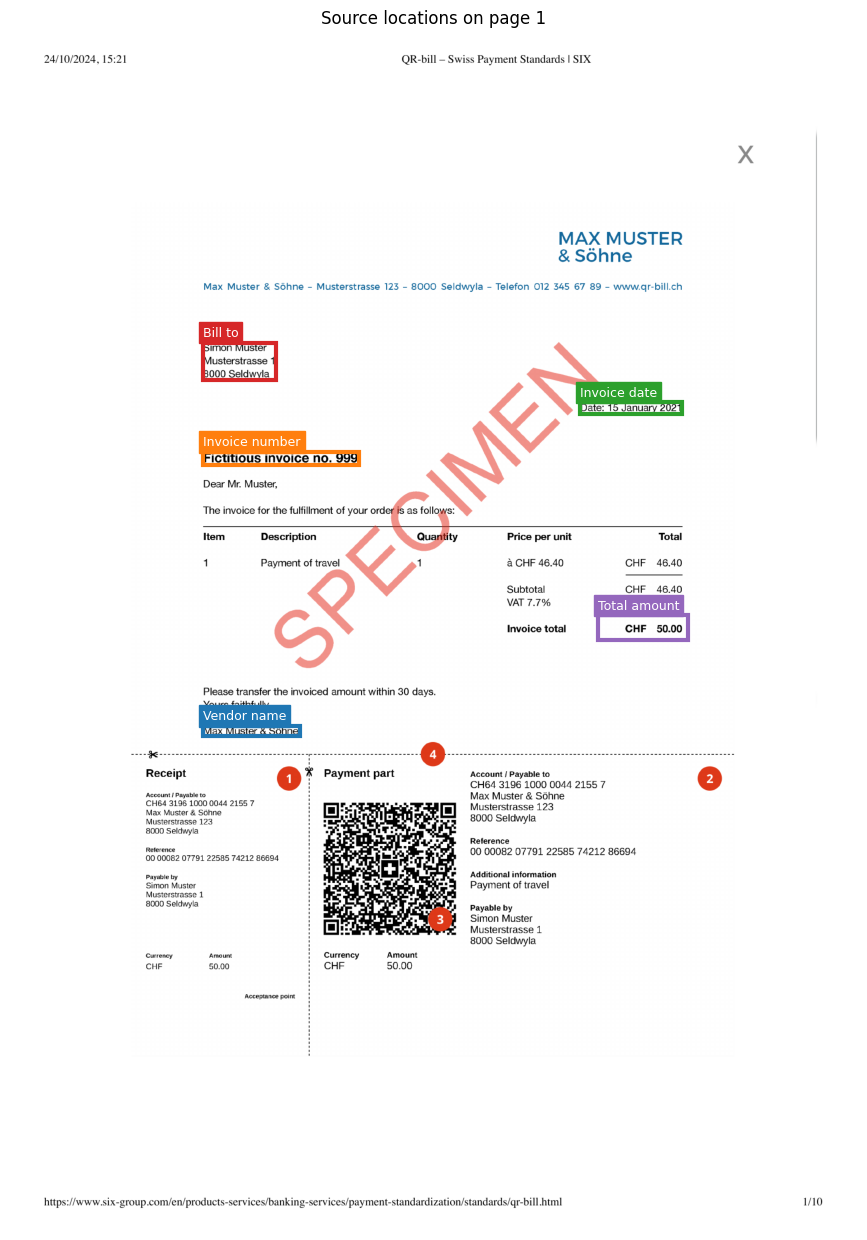

Rendered overlays:
 - outputs/source-locations-page-1.png


In [7]:
pages = {page["pageNumber"]: page for page in source_locations.get("pages", [])}
if not pages:
    raise RuntimeError("No page metadata returned with source locations")

page_images = {}
for page_number in sorted(pages):
    page_bytes = await client.get_image(job_id, page_number - 1)
    if page_bytes is None:
        raise RuntimeError(f"No image returned for page {page_number}")
    page_images[page_number] = Image.open(io.BytesIO(page_bytes)).convert("RGB")


def anchor_to_pixels(anchor: dict[str, Any], page_info: dict[str, Any], image: Image.Image) -> tuple[float, float, float, float]:
    bbox = anchor["bbox"]
    x_scale = image.width / float(page_info["width"])
    y_scale = image.height / float(page_info["height"])
    left = float(bbox["left"]) * x_scale
    top = float(bbox["top"]) * y_scale
    right = float(bbox["right"]) * x_scale
    bottom = float(bbox["bottom"]) * y_scale
    return left, top, max(right - left, 1.0), max(bottom - top, 1.0)


def render_page(page_number: int, pointer_labels: list[tuple[str, str]]) -> Path:
    page_info = pages[page_number]
    image = page_images[page_number]
    colors = plt.cm.tab10.colors
    fig, ax = plt.subplots(figsize=(11, 11 * image.height / image.width))
    ax.imshow(image)

    for index, (pointer, label) in enumerate(pointer_labels):
        entry = locations[pointer]
        color = colors[index % len(colors)]
        for anchor in entry.get("pageAnchors", []):
            if anchor.get("pageNumber") != page_number:
                continue
            left, top, width, height = anchor_to_pixels(anchor, page_info, image)
            ax.add_patch(
                Rectangle(
                    (left, top),
                    width,
                    height,
                    fill=False,
                    linewidth=3,
                    edgecolor=color,
                )
            )
            ax.text(
                left,
                max(top - 12, 16),
                label,
                color="white",
                fontsize=9,
                bbox={"facecolor": color, "edgecolor": color, "pad": 3},
            )

    ax.set_title(f"Source locations on page {page_number}")
    ax.axis("off")
    output_path = Path("outputs") / f"source-locations-page-{page_number}.png"
    fig.savefig(output_path, bbox_inches="tight", dpi=160)
    plt.show()
    return output_path


pointer_labels = [(pointer, label) for pointer, label in field_order if pointer in locations]
rendered_paths = []
for page_number in sorted(page_images):
    page_pointer_labels = [
        (pointer, label)
        for pointer, label in pointer_labels
        if any(anchor.get("pageNumber") == page_number for anchor in locations[pointer].get("pageAnchors", []))
    ]
    if not page_pointer_labels:
        continue
    rendered_paths.append(render_page(page_number, page_pointer_labels))

print("Rendered overlays:")
for path in rendered_paths:
    print(f" - {path}")
